<a href="https://colab.research.google.com/github/DanielRegaladoUMiami/counterflow-nn/blob/main/notebooks/00_run_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CounterFlow Neural Network (CFNN) — Phase 1 Experiments

This notebook runs all Phase 1 experiments:
1. **Setup**: Clone repo & install dependencies
2. **Unit Tests**: Verify conservation law, dimensions, gradients
3. **Tier 1 Synthetic**: Train CFNN on moons, circles, XOR
4. **Baseline Comparison**: CFNN vs MLP vs ResMLP on 6 datasets
5. **Visualization**: Decision boundaries

**Author:** Daniel Regalado Cardoso | University of Miami

## 1. Setup

In [1]:
# Clone the repo
!git clone https://github.com/DanielRegaladoUMiami/counterflow-nn.git
%cd counterflow-nn

Cloning into 'counterflow-nn'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 44 (delta 7), reused 38 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 43.13 KiB | 6.16 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/counterflow-nn


In [2]:
# Install dependencies (torch is pre-installed in Colab)
!pip install scikit-learn matplotlib pandas pytest -q

In [3]:
# Verify imports
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

from src.plates import CounterFlowPlate
from src.network import CounterFlowNetwork
from src.activations import MichaelisMenten, Arrhenius, HillActivation, Autocatalytic
from src.utils import load_synthetic_dataset, prepare_data, train_model
print("All imports successful!")

PyTorch: 2.10.0+cu128
CUDA available: True
All imports successful!


## 2. Unit Tests — Verify Conservation & Dimensions

In [4]:
!python -m pytest tests/test_plates.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/counterflow-nn
configfile: pyproject.toml
plugins: typeguard-4.5.1, anyio-4.12.1, langsmith-0.7.16
collected 16 items                                                             

tests/test_plates.py::TestCounterFlowPlate::test_output_dimensions PASSED [  6%]
tests/test_plates.py::TestCounterFlowPlate::test_conservation_law PASSED [ 12%]
tests/test_plates.py::TestCounterFlowPlate::test_conservation_via_delta PASSED [ 18%]
tests/test_plates.py::TestCounterFlowPlate::test_alpha_positive PASSED   [ 25%]
tests/test_plates.py::TestCounterFlowPlate::test_alpha_init_value PASSED [ 31%]
tests/test_plates.py::TestCounterFlowPlate::test_gradients_flow PASSED   [ 37%]
tests/test_plates.py::TestCounterFlowPlate::test_zero_liquid_nonzero_transfer PASSED [ 43%]
tests/test_plates.py::TestCounterFlow

## 3. Quick Sanity Check — Does CFNN Learn?

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load synthetic data
X, y = load_synthetic_dataset("moons", n_samples=1000, noise=0.2, seed=42)
train_loader, test_loader, d_in, n_classes = prepare_data(X, y, seed=42)

# Create CFNN
model = CounterFlowNetwork(
    d_in=d_in, d_gas=32, d_liquid=32,
    n_plates=5, d_out=n_classes, n_sweeps=2
)
print(f"CFNN-A Parameters: {model.count_parameters()}")
print(f"Architecture: {model}")

CFNN-A Parameters: 4386
Architecture: CounterFlowNetwork(
  d_in=2, d_gas=32, d_liquid=32, n_plates=5, d_out=2, n_sweeps=2, share_plates=True, params=4386
  (gas_encoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
  )
  (_shared_plate): CounterFlowPlate(
    d_gas=32, d_liquid=32, alpha_mean=0.1000
    (equilibrium): Linear(in_features=32, out_features=32, bias=True)
    (transfer): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): Tanh()
    )
  )
  (output_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [6]:
# Train!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
history = train_model(
    model, train_loader, test_loader,
    n_epochs=100, lr=1e-3, device=device,
    verbose=True, print_every=10
)

Epoch   10 | Train: 0.1883 | Test: 0.1121 | accuracy: 0.9650
Epoch   20 | Train: 0.0848 | Test: 0.0390 | accuracy: 0.9900
Epoch   30 | Train: 0.0735 | Test: 0.0260 | accuracy: 0.9900
Epoch   40 | Train: 0.0707 | Test: 0.0267 | accuracy: 0.9900
Epoch   50 | Train: 0.0665 | Test: 0.0241 | accuracy: 0.9900
Epoch   60 | Train: 0.0682 | Test: 0.0220 | accuracy: 0.9950
Epoch   70 | Train: 0.0703 | Test: 0.0220 | accuracy: 0.9950
Epoch   80 | Train: 0.0656 | Test: 0.0227 | accuracy: 0.9900
Epoch   90 | Train: 0.0719 | Test: 0.0241 | accuracy: 0.9950
Epoch  100 | Train: 0.0684 | Test: 0.0235 | accuracy: 0.9950


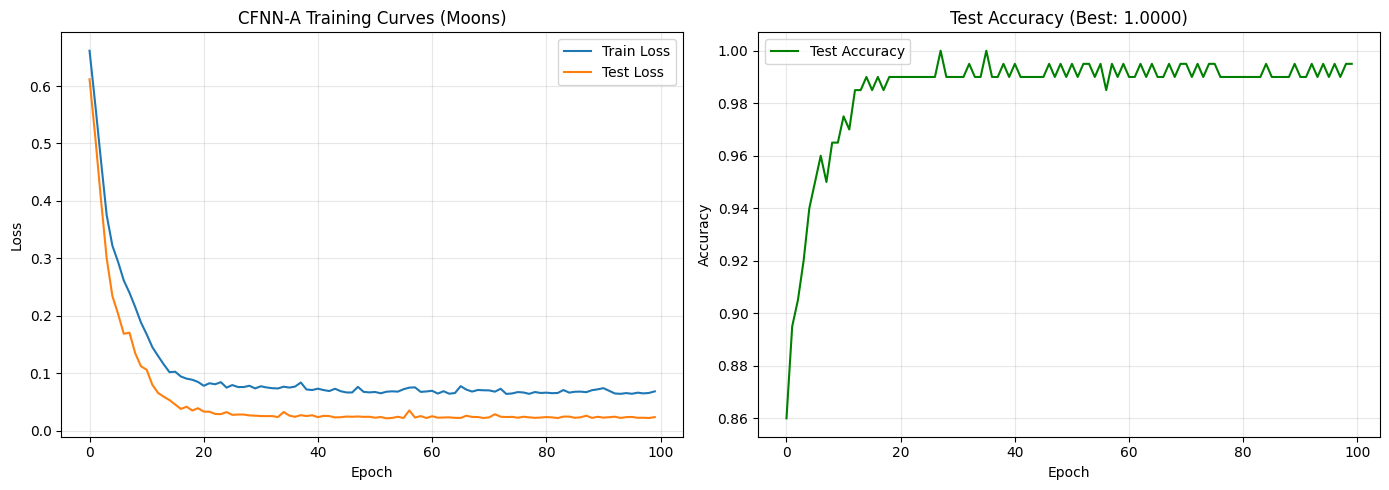

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_losses'], label='Train Loss')
ax1.plot(history['test_losses'], label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('CFNN-A Training Curves (Moons)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['test_metrics'], label='Test Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title(f'Test Accuracy (Best: {max(history["test_metrics"]):.4f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Decision Boundary Visualization

In [8]:
from sklearn.preprocessing import StandardScaler

def plot_decision_boundary(model, X, y, title="", ax=None, device="cpu"):
    """Plot 2D decision boundary."""
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(6, 5))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    h = 0.02
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)

    model.eval()
    with torch.no_grad():
        Z = model(grid).argmax(-1).cpu().numpy().reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=20)
    ax.set_title(title)
    return ax

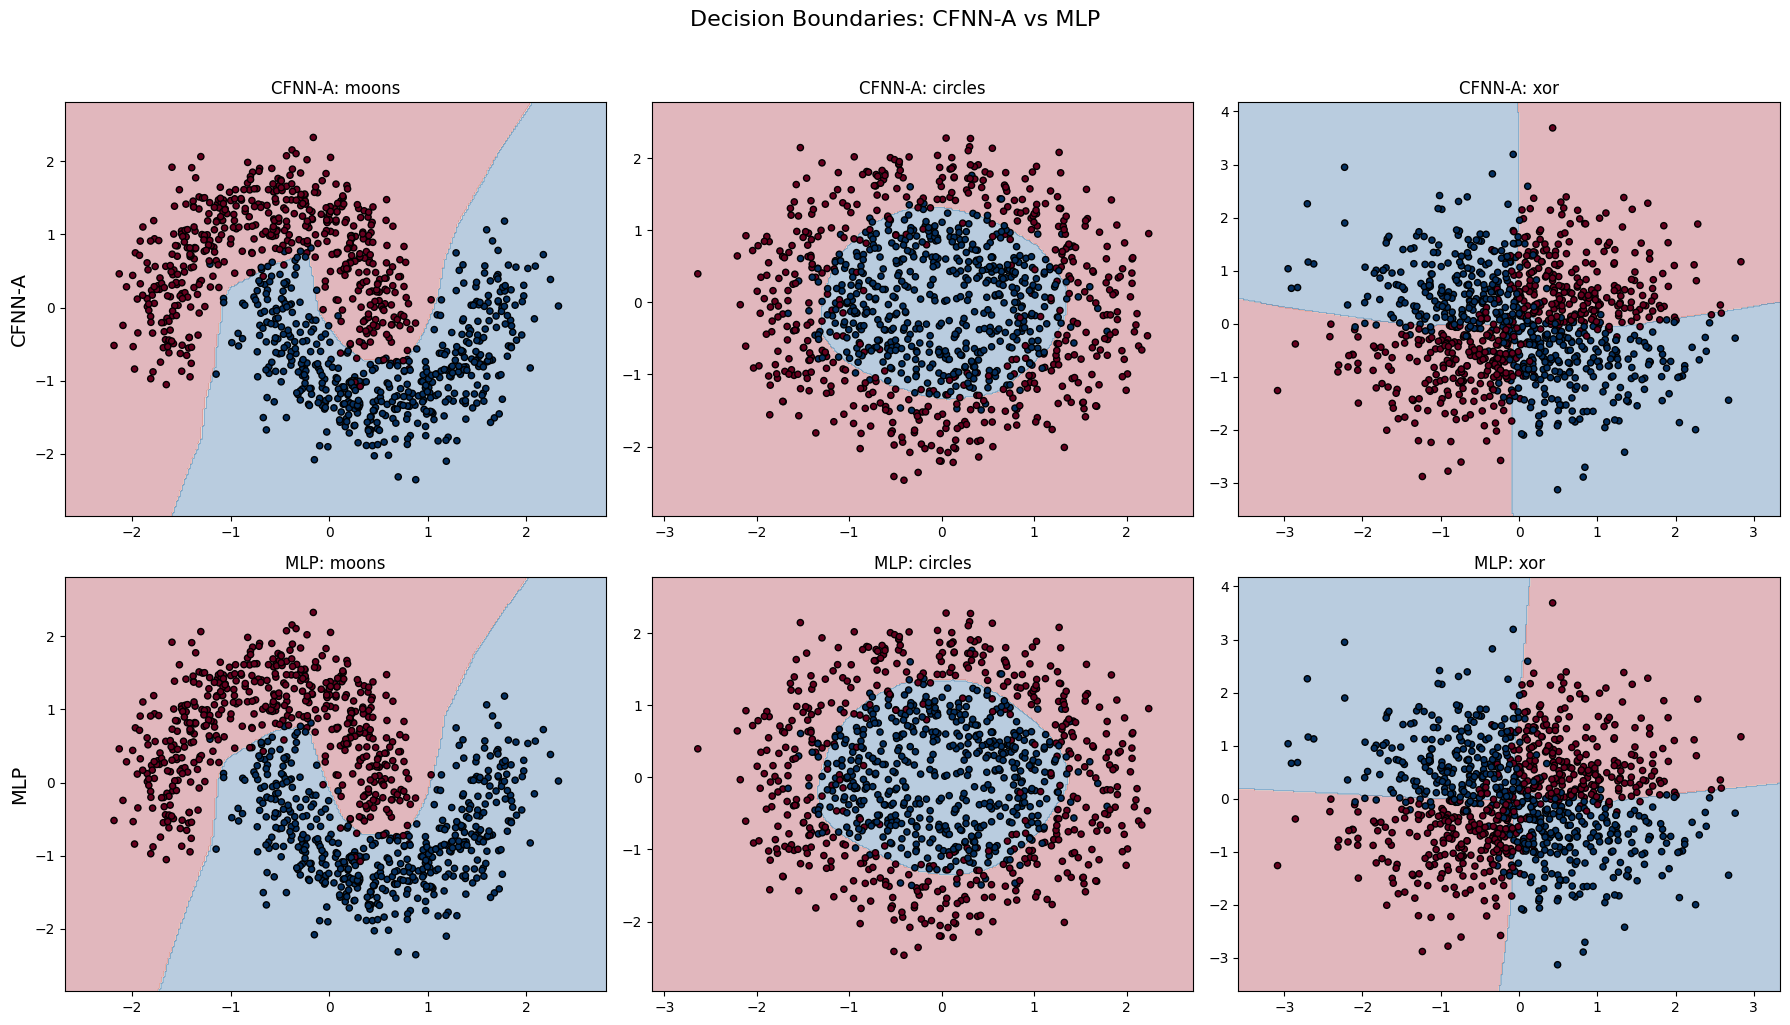

In [9]:
# Train CFNN and MLP on all 3 synthetic datasets and plot boundaries
from experiments.tier1_synthetic import MLPBaseline

datasets = ['moons', 'circles', 'xor']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, ds_name in enumerate(datasets):
    X, y = load_synthetic_dataset(ds_name, n_samples=1000, seed=42)
    train_ld, test_ld, d_in, n_cls = prepare_data(X, y, seed=42)

    # CFNN
    cfnn = CounterFlowNetwork(d_in=d_in, d_gas=32, d_liquid=32, n_plates=5, d_out=n_cls)
    train_model(cfnn, train_ld, test_ld, n_epochs=100, device=device, verbose=False)
    cfnn.to('cpu')
    plot_decision_boundary(cfnn, X, y, f'CFNN-A: {ds_name}', axes[0, i])

    # MLP
    mlp = MLPBaseline(d_in=d_in, d_hidden=45, d_out=n_cls)
    train_model(mlp, train_ld, test_ld, n_epochs=100, device=device, verbose=False)
    mlp.to('cpu')
    plot_decision_boundary(mlp, X, y, f'MLP: {ds_name}', axes[1, i])

axes[0, 0].set_ylabel('CFNN-A', fontsize=14)
axes[1, 0].set_ylabel('MLP', fontsize=14)
plt.suptitle('Decision Boundaries: CFNN-A vs MLP', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 5. Full Baseline Comparison (5 seeds × 6 datasets)

In [10]:
# This runs the full comparison script
# Takes ~5-10 minutes depending on hardware
!python experiments/compare_baselines.py

Running moons...
Running circles...
Running xor...
Running iris...
Running wine...
Running breast_cancer...

RESULTS SUMMARY
                        mean     std
dataset       model                 
breast_cancer CFNN-A  0.9807  0.0073
              MLP     0.9789  0.0100
              ResMLP  0.9842  0.0073
circles       CFNN-A  0.9150  0.0194
              MLP     0.9140  0.0147
              ResMLP  0.9140  0.0175
iris          CFNN-A  0.9733  0.0279
              MLP     0.9600  0.0723
              ResMLP  0.9600  0.0548
moons         CFNN-A  0.9850  0.0117
              MLP     0.9820  0.0135
              ResMLP  0.9840  0.0139
wine          CFNN-A  0.9944  0.0124
              MLP     1.0000  0.0000
              ResMLP  0.9944  0.0124
xor           CFNN-A  0.8910  0.0305
              MLP     0.8880  0.0340
              ResMLP  0.8880  0.0293

Saved to experiments/results/baseline_comparison.csv


## 6. Internal Dynamics — What's happening inside CFNN?

In [11]:
# Train a model and inspect its internals
X, y = load_synthetic_dataset('moons', n_samples=1000, seed=42)
train_ld, test_ld, d_in, n_cls = prepare_data(X, y, seed=42)

model = CounterFlowNetwork(d_in=d_in, d_gas=32, d_liquid=32, n_plates=8, d_out=n_cls, n_sweeps=2)
train_model(model, train_ld, test_ld, n_epochs=150, device=device, verbose=True, print_every=25)
model.to('cpu')

# Get intermediates
X_tensor = torch.FloatTensor(StandardScaler().fit_transform(X))
result = model.forward_with_intermediates(X_tensor)

Epoch   25 | Train: 0.0776 | Test: 0.0301 | accuracy: 0.9900
Epoch   50 | Train: 0.0744 | Test: 0.0244 | accuracy: 0.9900
Epoch   75 | Train: 0.0742 | Test: 0.0249 | accuracy: 0.9900
Epoch  100 | Train: 0.0731 | Test: 0.0228 | accuracy: 0.9900
Epoch  125 | Train: 0.0666 | Test: 0.0225 | accuracy: 0.9900
Epoch  150 | Train: 0.0669 | Test: 0.0242 | accuracy: 0.9950


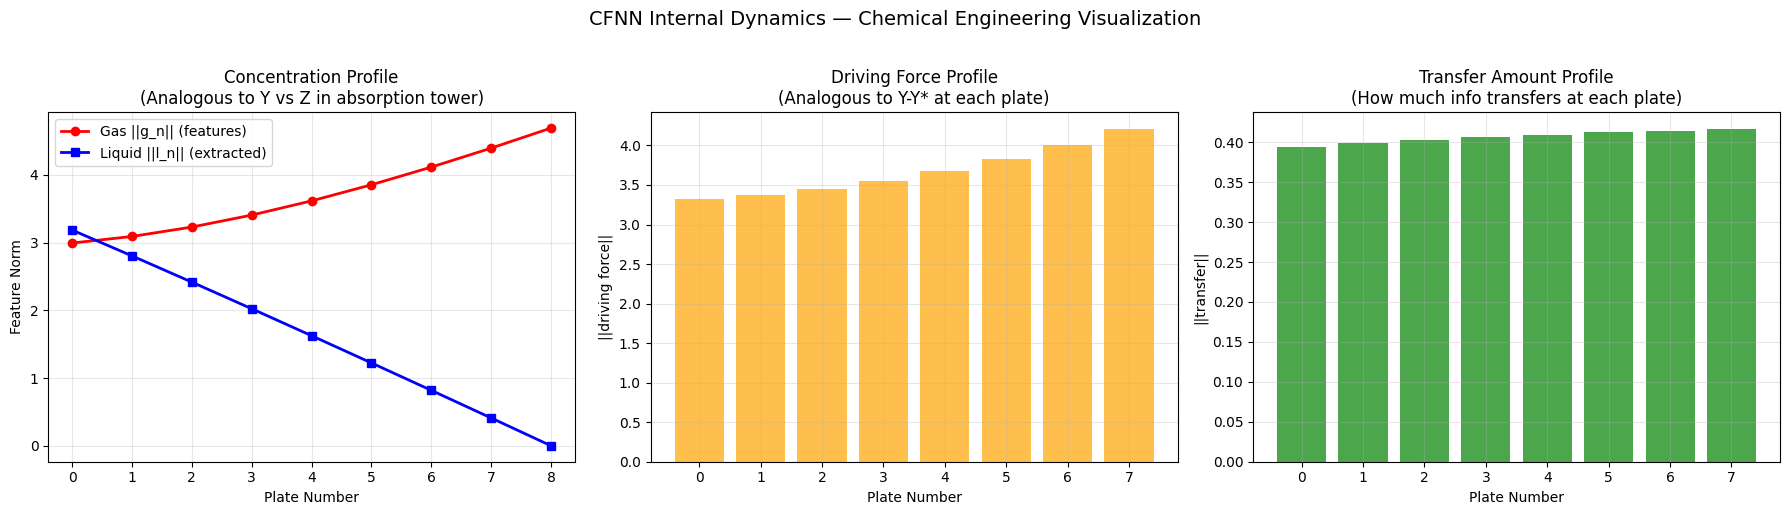

In [12]:
# Plot concentration profiles (gas and liquid norms through the tower)
gas_norms = [g.norm(dim=-1).mean().item() for g in result['gas_states']]
liquid_norms = [l.norm(dim=-1).mean().item() for l in result['liquid_states']]
delta_norms = [d.norm(dim=-1).mean().item() for d in result['deltas']]
df_norms = [d.norm(dim=-1).mean().item() for d in result['driving_forces']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Concentration profile
axes[0].plot(range(len(gas_norms)), gas_norms, 'r-o', label='Gas ||g_n|| (features)', linewidth=2)
axes[0].plot(range(len(liquid_norms)), liquid_norms, 'b-s', label='Liquid ||l_n|| (extracted)', linewidth=2)
axes[0].set_xlabel('Plate Number')
axes[0].set_ylabel('Feature Norm')
axes[0].set_title('Concentration Profile\n(Analogous to Y vs Z in absorption tower)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Driving force profile
axes[1].bar(range(len(df_norms)), df_norms, color='orange', alpha=0.7)
axes[1].set_xlabel('Plate Number')
axes[1].set_ylabel('||driving force||')
axes[1].set_title('Driving Force Profile\n(Analogous to Y-Y* at each plate)')
axes[1].grid(True, alpha=0.3)

# Transfer amount profile
axes[2].bar(range(len(delta_norms)), delta_norms, color='green', alpha=0.7)
axes[2].set_xlabel('Plate Number')
axes[2].set_ylabel('||transfer||')
axes[2].set_title('Transfer Amount Profile\n(How much info transfers at each plate)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('CFNN Internal Dynamics — Chemical Engineering Visualization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Test ChemE Activations

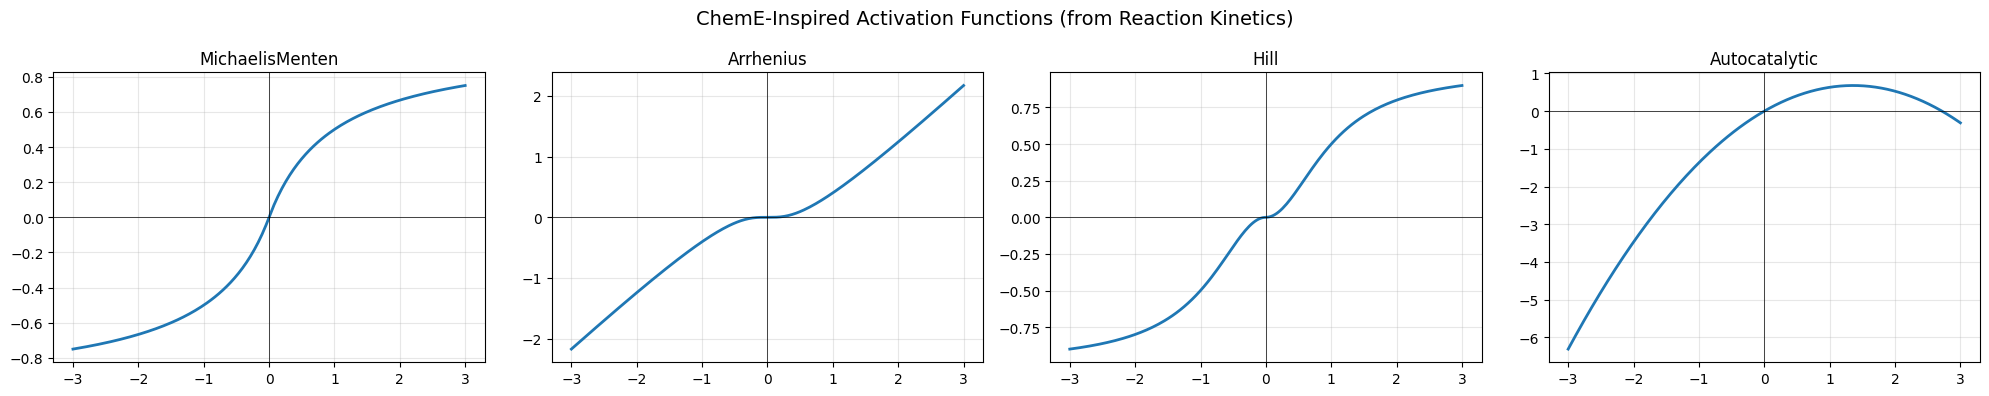

In [13]:
# Visualize the ChemE activation functions
x = torch.linspace(-3, 3, 200)

activations = {
    'MichaelisMenten': MichaelisMenten(1),
    'Arrhenius': Arrhenius(1),
    'Hill': HillActivation(1),
    'Autocatalytic': Autocatalytic(1),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, act) in zip(axes, activations.items()):
    with torch.no_grad():
        y_act = act(x.unsqueeze(-1)).squeeze()
    ax.plot(x.numpy(), y_act.numpy(), linewidth=2)
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

plt.suptitle('ChemE-Inspired Activation Functions (from Reaction Kinetics)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Done!

**Next steps (Phase 2):**
- Implement CFNN-D (distillation mode with bidirectional transfer)
- Benchmark on MNIST / FashionMNIST
- McCabe-Thiele neural visualization